In [41]:
!pip install neurokit2

In [42]:
!pip install mne

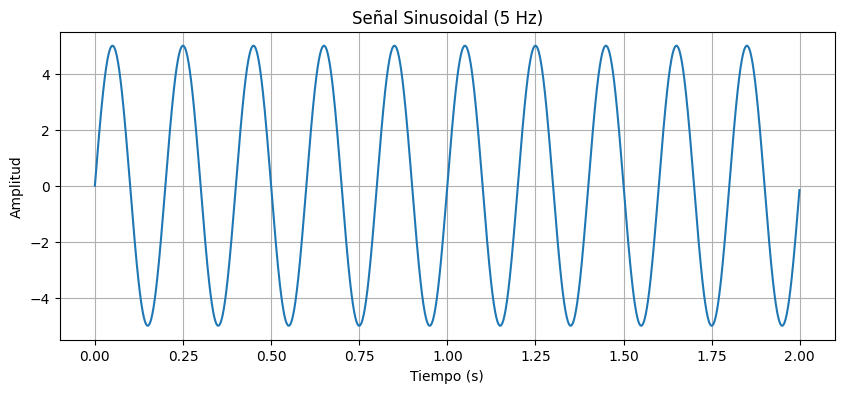

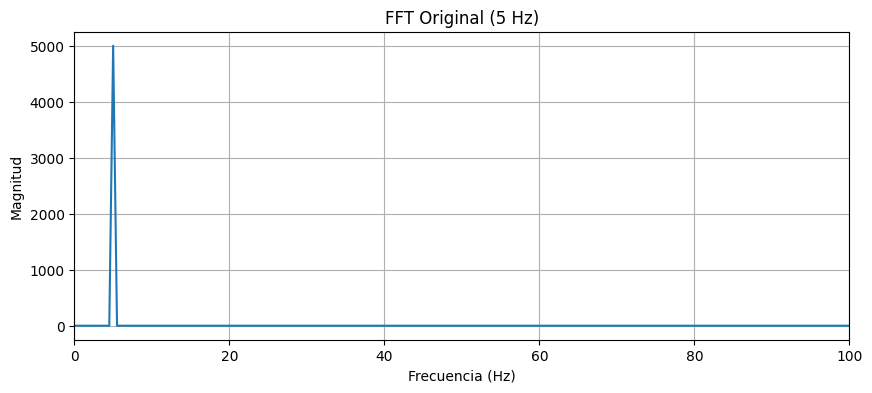

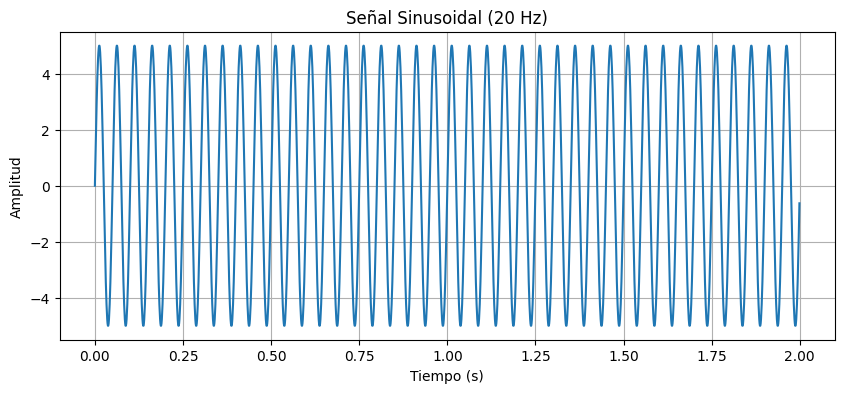

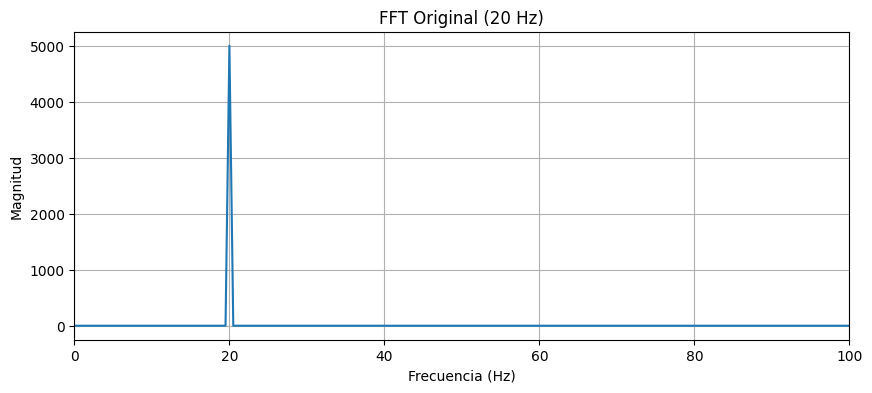

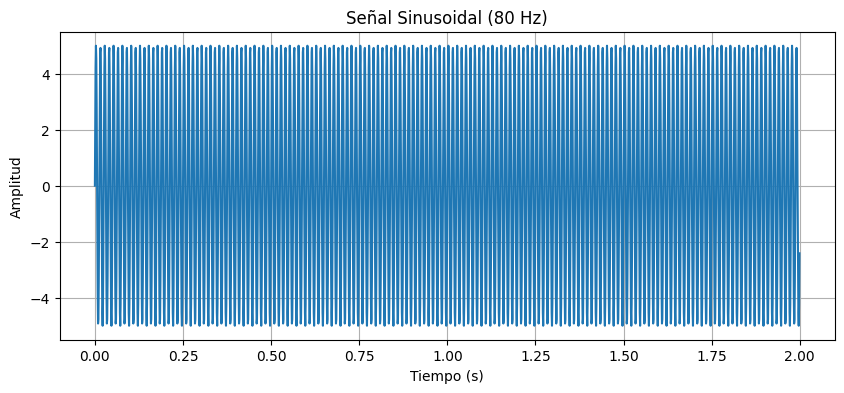

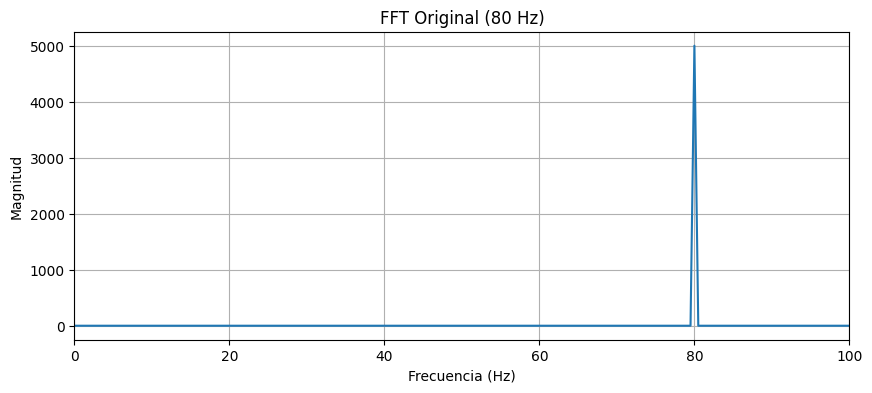

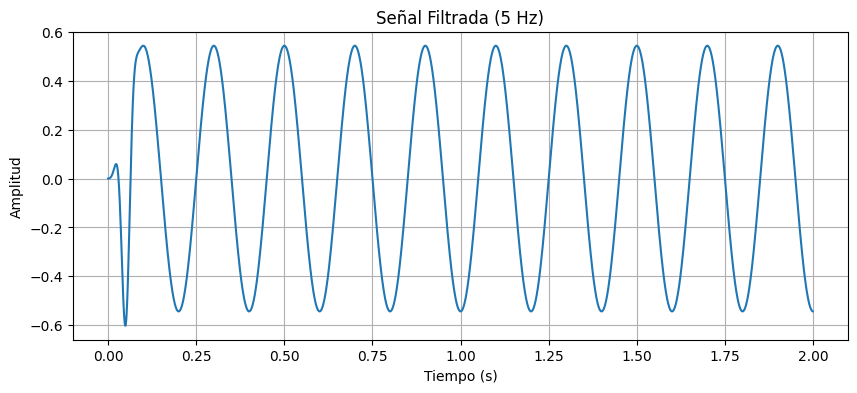

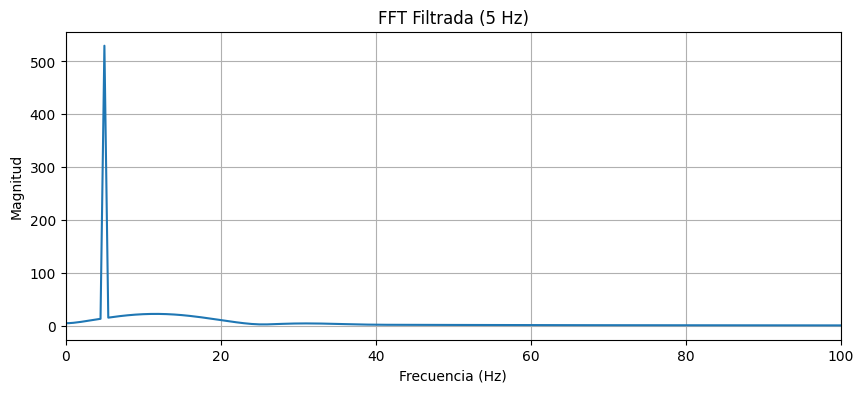

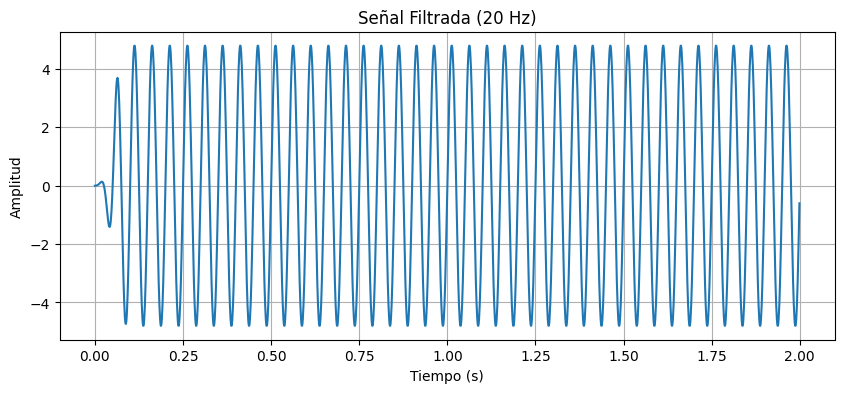

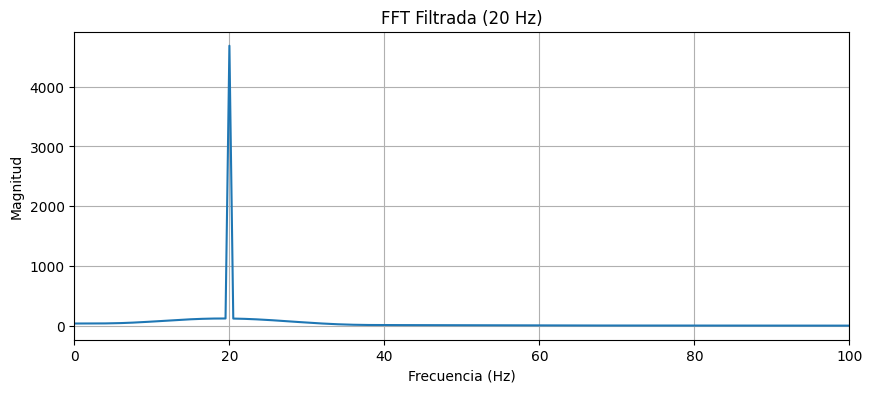

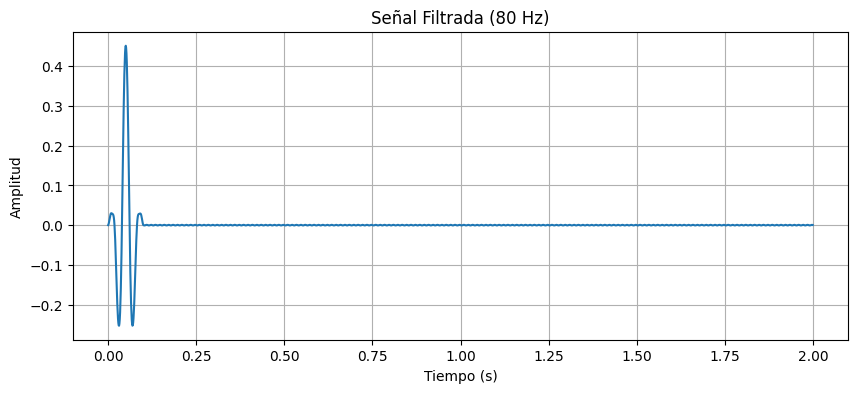

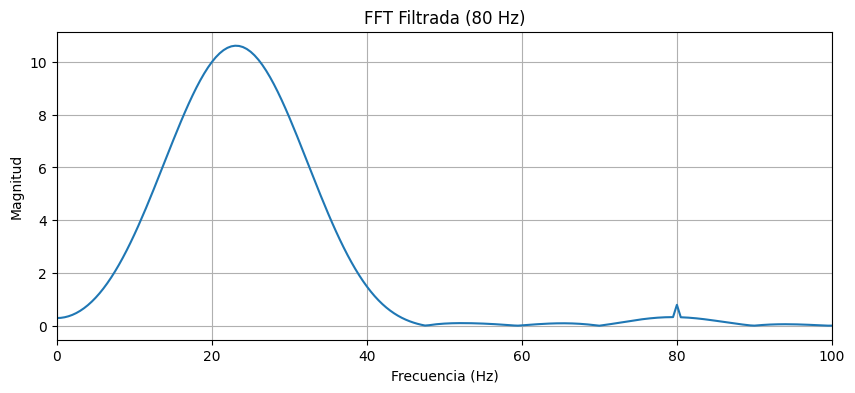

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Ejercicio 1

# Señales de 5, 20 y 80 Hz

fs = 1000           # Frecuencia de muestreo
duration = 2        # Duración en segundos
amplitude = 5
phase = 0

# Vector de tiempo
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# Frecuencias
frequencies = [5, 20, 80]

signals = []

for f in frequencies:
    sig = amplitude * np.sin(2 * np.pi * f * t + phase)
    signals.append(sig)

    # FFT señal original
    fft_original = np.fft.fft(sig)
    freq = np.fft.fftfreq(len(sig), 1/fs)
    positive = freq >= 0

    plt.figure(figsize=(10,4))
    plt.plot(t, sig)
    plt.title(f'Señal Sinusoidal ({f} Hz)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(freq[positive],
         np.abs(fft_original[positive]))

    plt.title(f'FFT Original ({f} Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.grid(True)
    plt.xlim(0, 100)
    plt.show()


# Filtro FIR pasa banda 15-30 Hz

# Orden del filtro
numtaps = 101

# Diseño del filtro FIR
fir = signal.firwin(
    numtaps,
    [15, 30],
    pass_zero=False,
    fs=fs
)

# Filtrar señales
filtered_signals = []

for i, sig in enumerate(signals):

    filtered = signal.lfilter(fir, 1.0, sig)
    filtered_signals.append(filtered)

    # FFT señal filtrada
    fft_filtrada = np.fft.fft(filtered)
    freq = np.fft.fftfreq(len(filtered), 1/fs)
    positive = freq >= 0

    plt.figure(figsize=(10,4))
    plt.plot(t, filtered)
    plt.title(f'Señal Filtrada ({frequencies[i]} Hz)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(freq[positive],
         np.abs(fft_filtrada[positive]))

    plt.title(f'FFT Filtrada ({frequencies[i]} Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.grid(True)
    plt.xlim(0, 100)
    plt.show()

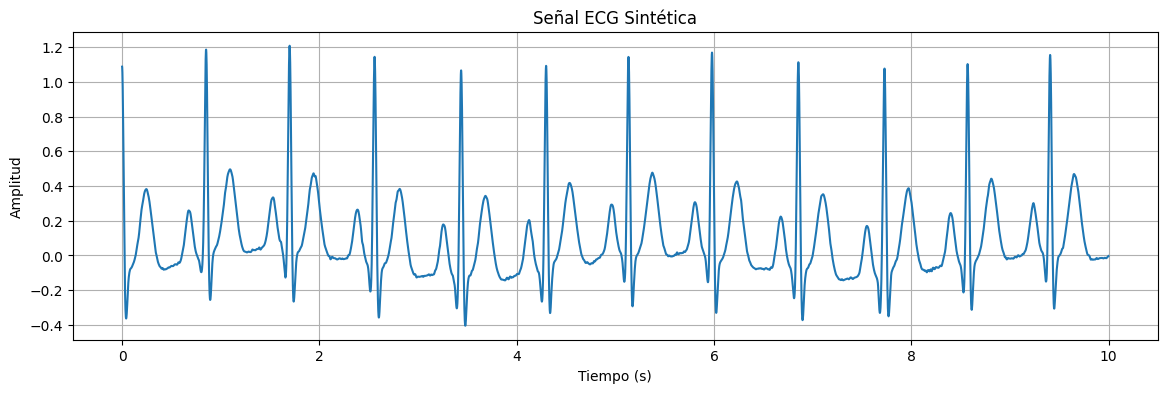

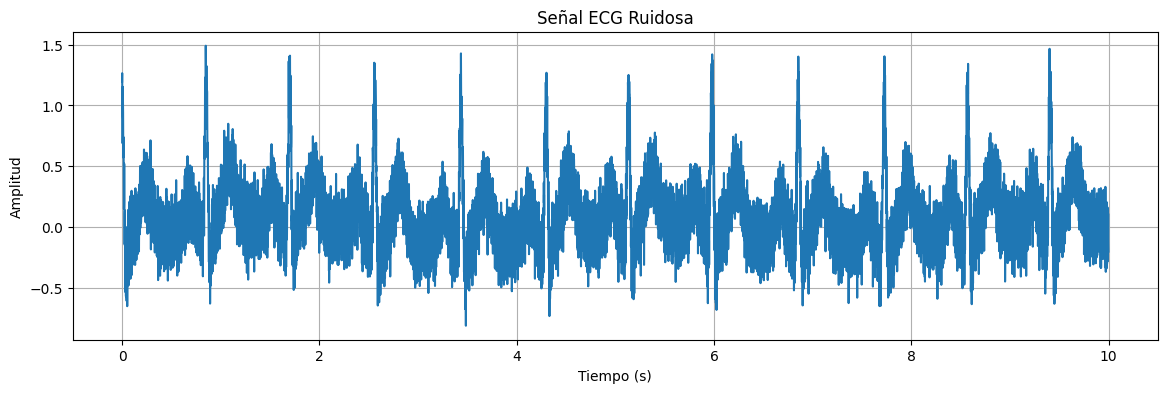

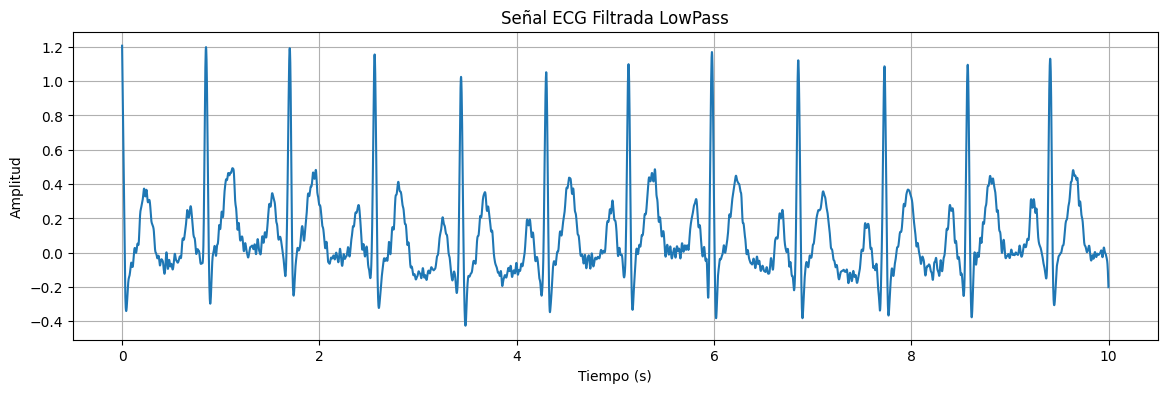

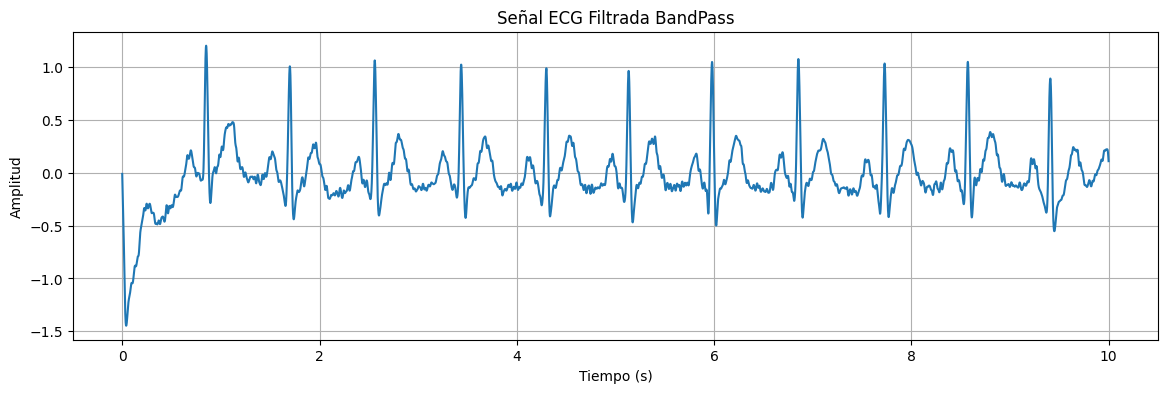

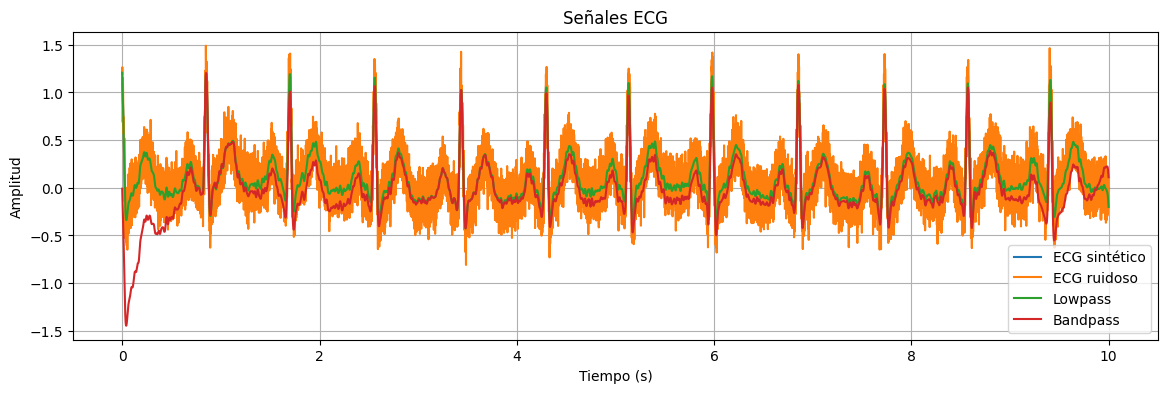

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import neurokit2 as nk

# Ejercicio 2

#Parámetros
Fs = 1000           # Frecuencia de muestreo
duration = 10       # Duración (s)
t = np.linspace(0, duration, int(Fs * duration), endpoint=False)


# ECG sintético
ecg1 = nk.ecg_simulate(duration=10, sampling_rate=1000)

# Ruido blanco
rui_blan = np.random.normal(0, 0.1, size=len(ecg1))   # np.random.normal(mean, std, size)

# Interferencia de alta frecuencia
high_int = 0.2 * np.sin(2 * np.pi * 150 * t)        # Señal sinusoidal de 150 Hz

# Señal ECG ruidosa
ecg_noise = ecg1 + rui_blan + high_int

# Diseño de filtro lowpass
b_low , a_low = signal.butter(4, 40, btype='low', fs=Fs)
ecg_low = signal.filtfilt(b_low, a_low, ecg_noise)

# Diseño de filtro bandpass
b_band , a_band = signal.butter(4, [0.5, 40], btype='bandpass', fs=Fs)
ecg_band = signal.filtfilt(b_band, a_band, ecg_noise)

# Ploteo de señales
plt.figure(figsize=(14,4))
plt.plot(t, ecg1)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal ECG Sintética")
plt.grid(True)
plt.show()

plt.figure(figsize=(14,4))
plt.plot(t, ecg_noise)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal ECG Ruidosa")
plt.grid(True)
plt.show()

plt.figure(figsize=(14,4))
plt.plot(t, ecg_low)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal ECG Filtrada LowPass")
plt.grid(True)
plt.show()

plt.figure(figsize=(14,4))
plt.plot(t, ecg_band)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal ECG Filtrada BandPass")
plt.grid(True)
plt.show()

plt.figure(figsize=(14,4))
plt.plot(t, ecg1, label='ECG sintético')
plt.plot(t, ecg_noise, label='ECG ruidoso')
plt.plot(t, ecg_low, label='Lowpass')
plt.plot(t, ecg_band, label='Bandpass')

plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señales ECG")
plt.legend()
plt.grid(True)
plt.show()

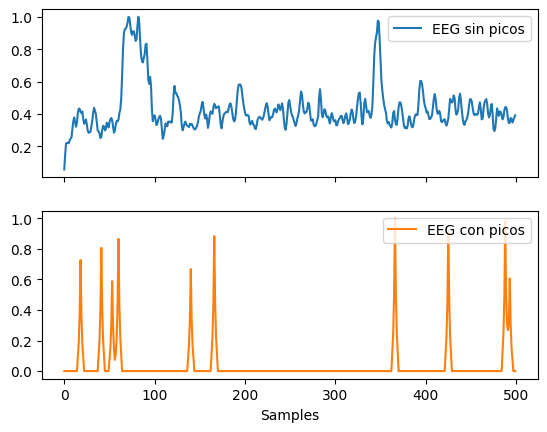

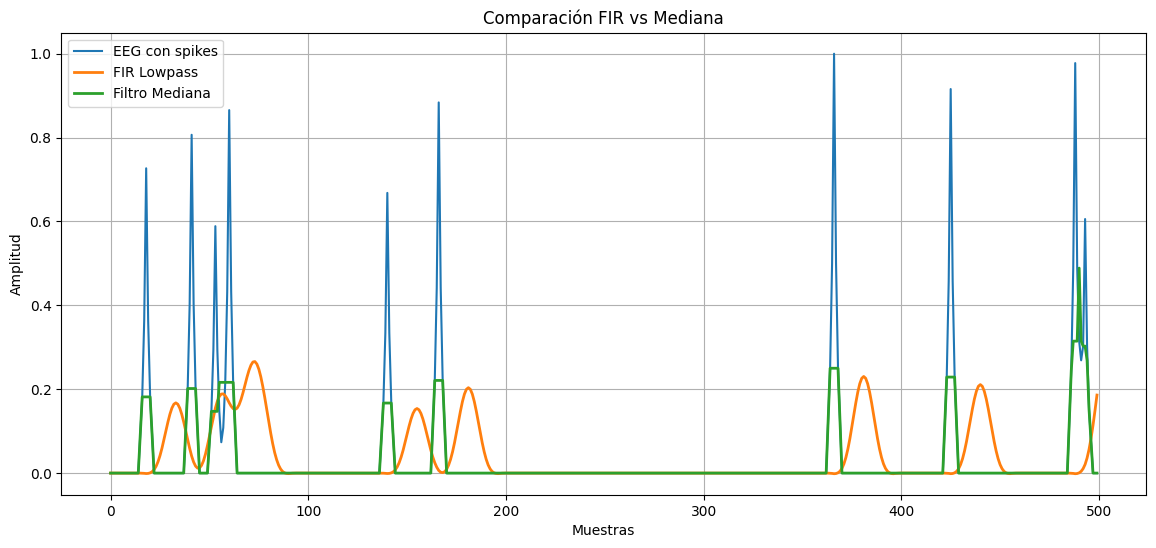

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import neurokit2 as nk

# Ejercicio 3

eeg = nk.mne_data("filt-0-40_raw")
eeg = nk.eeg_rereference(eeg, 'average')
eeg = eeg.get_data()[:, 0:500]

# Copia de la señal
eeg_spikes = eeg.copy()

# Número de spikes
num_spikes = 10

# Dimensiones
n_channels, n_samples = eeg.shape

for _ in range(num_spikes):

    # Canal aleatorio
    ch = np.random.randint(0, n_channels)

    # Tiempo aleatorio
    pos = np.random.randint(3, n_samples-3)

    # Amplitud aleatoria
    amplitude = np.random.uniform(2,5)

    # Insertar spike
    shape = np.array([0.5, 1, 2, 4, 2, 1, 0.5])

    eeg_spikes[ch, pos-3:pos+4] += amplitude * shape


# GFP de las señales EEG
eeg_np = nk.eeg_gfp(eeg, method="l1", normalize=True)

eeg_p = nk.eeg_gfp(eeg_spikes, method="l1", normalize=True)

nk.signal_plot([eeg_np, eeg_p], subplots = True, labels=["EEG sin picos",
                                                         "EEG con picos"])


# Diseño de filtro lowpass y aplicación a la señal
b_fir = signal.firwin(numtaps=31, cutoff=40, fs=1000)
eeg_fir = signal.lfilter(b_fir, 1.0, eeg_p)

# Diseño de filtro mediana y aplicación a la señal
eeg_median = signal.medfilt(eeg_p, kernel_size=7)


# Comparamos ambos filtros

plt.figure(figsize=(14,6))
plt.plot(eeg_p, label='EEG con spikes')
plt.plot(eeg_fir, label='FIR Lowpass', linewidth=2)
plt.plot(eeg_median, label='Filtro Mediana', linewidth=2)
plt.title("Comparación FIR vs Mediana")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

# Ambos filtros logran reducir parcialmente el ruido causado por los spikes.
# Pero ambos tienen efectos distintos en la señal. El filtro FIR lowpass
# reduce los spikes, pero no los desaparece por completo, en cambio, los
# suaviza de tal forma que genera ensanchaciones en la señal. El filtro mediana
# realiza un mejor trabajo en reducir estos picos sin dañar la morfología
# de la señal, ya que calcula la mediana de valores en una ventana local,
# eliminando valores abruptos.

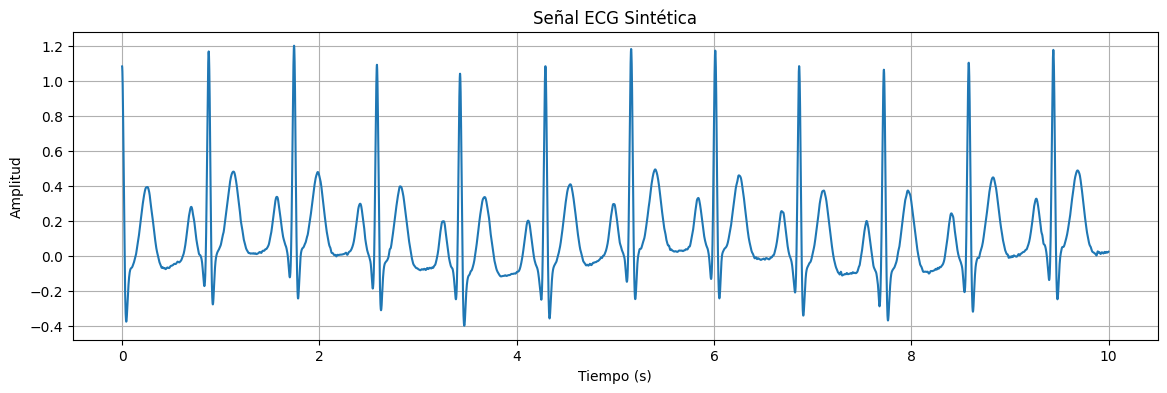

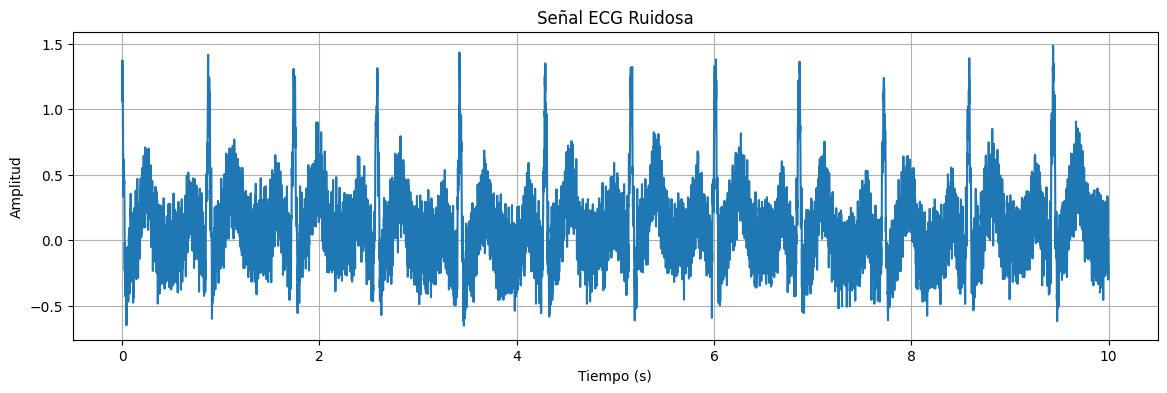

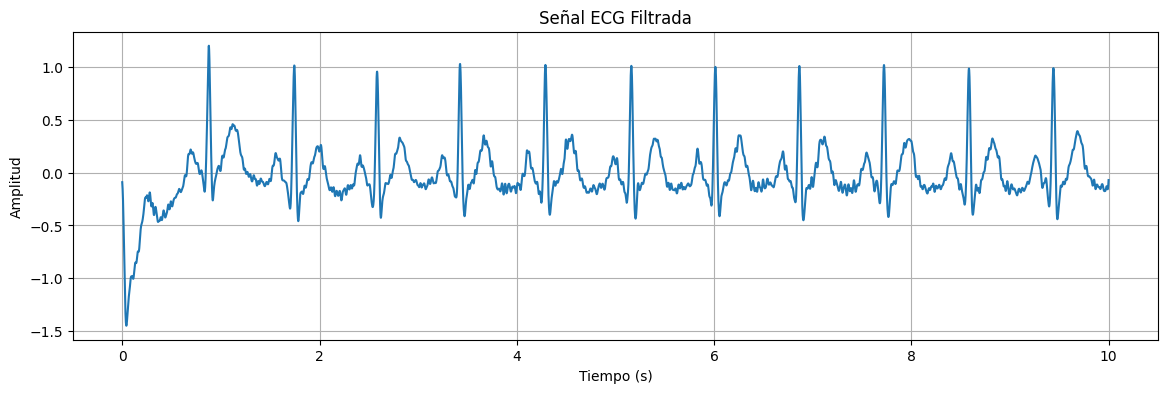

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import neurokit2 as nk

# Ejercicio 4

#Parámetros
Fs = 1000           # Frecuencia de muestreo
duration = 10       # Duración (s)
t = np.linspace(0, duration, int(Fs * duration), endpoint=False)

# ECG sintético
ecg1 = nk.ecg_simulate(duration=10, sampling_rate=1000)

# Ruido blanco
rui_blan = np.random.normal(0, 0.1, size=len(ecg1))   # np.random.normal(mean, std, size)

# Interferencia eléctrica
energ_int = 0.2 * np.sin(2 * np.pi * 60 * t)          # Señal sinusoidal de 60 Hz

# Señal ECG ruidosa
ecg_noise = ecg1 + rui_blan + energ_int

# Filtrado de la señal de interferencia eléctrica
b_ener, a_ener = signal.iirnotch(60, 30, Fs)
ecg_flt_emer = signal.filtfilt(b_ener, a_ener, ecg_noise)

# Filtrado de la señal de ruido blanco
b_band , a_band = signal.butter(4, [0.5, 40], btype='bandpass', fs=Fs)
ecg_flt_full = signal.filtfilt(b_band, a_band, ecg_flt_emer)

# Ploteo de señales
plt.figure(figsize=(14,4))
plt.plot(t, ecg1)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal ECG Sintética")
plt.grid(True)
plt.show()

plt.figure(figsize=(14,4))
plt.plot(t, ecg_noise)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal ECG Ruidosa")
plt.grid(True)
plt.show()

plt.figure(figsize=(14,4))
plt.plot(t, ecg_flt_full)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal ECG Filtrada")
plt.grid(True)
plt.show()


Delay ECG: 2000 muestras
Delay Respiración: 2000 muestras
Delay Acelerómetro: 82 muestras

Delay ECG: 2.0 s
Delay Respiración: 2.0 s
Delay Acelerómetro: 0.082 s


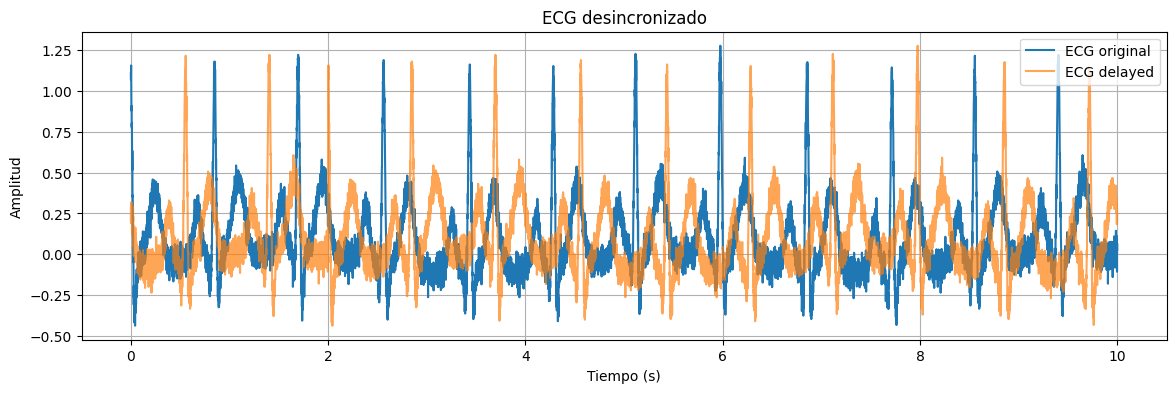

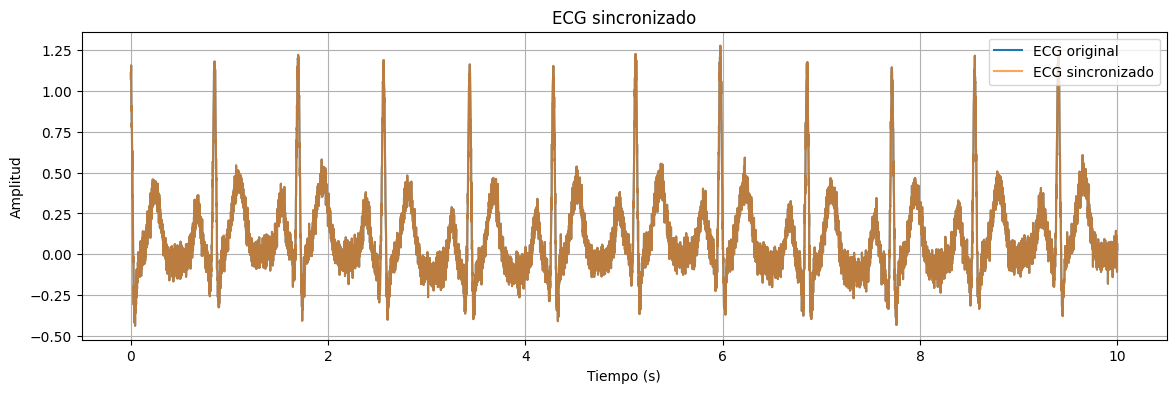

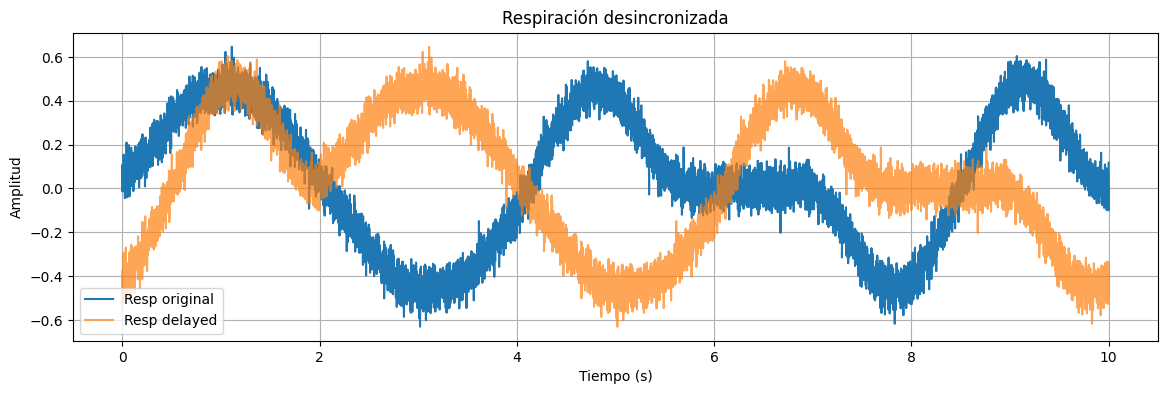

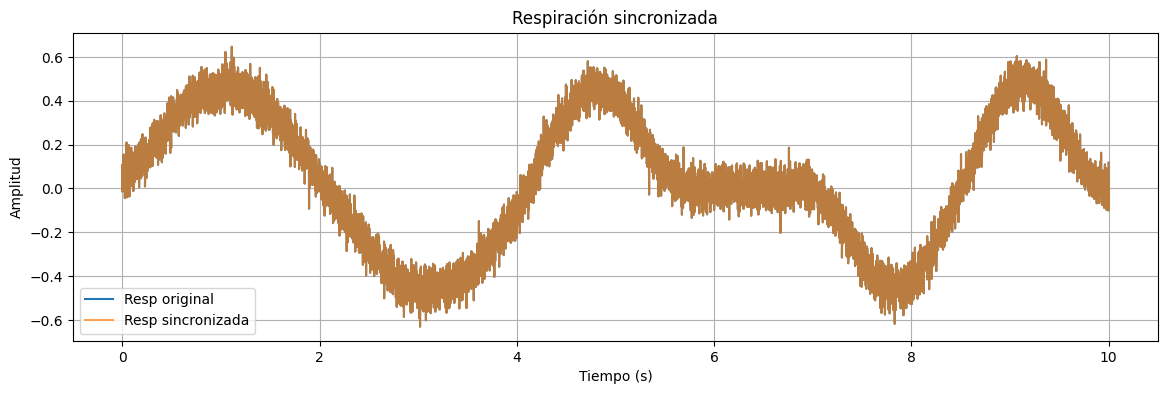

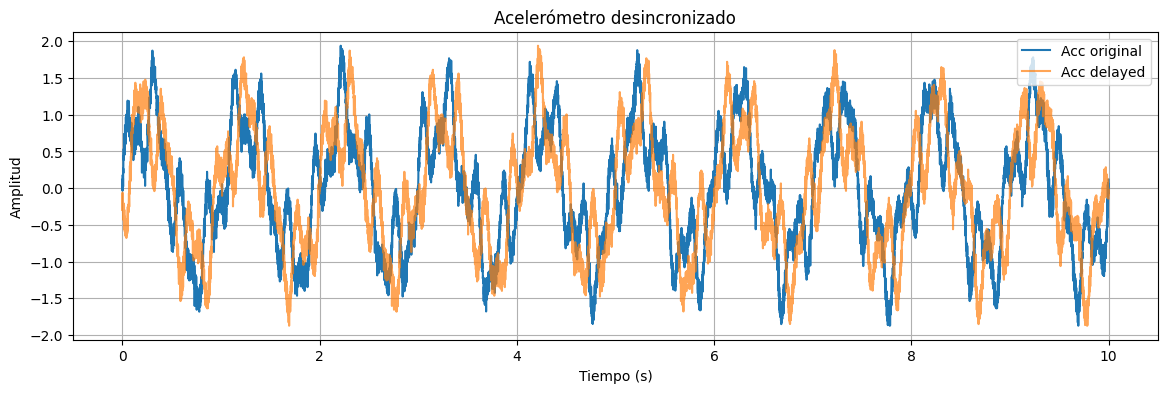

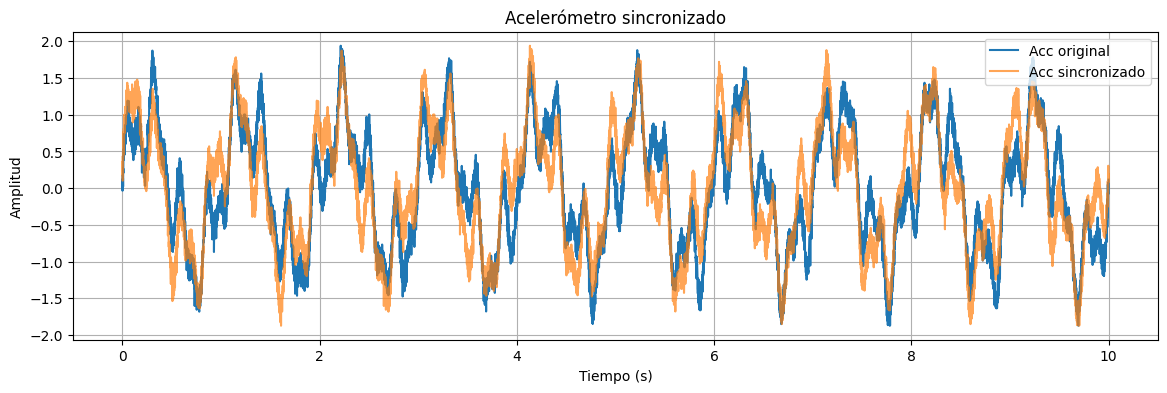

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
import neurokit2 as nk

# Ejercicio 5

# Parámetros
fs = 1000
duration = 10

t = np.linspace(0, duration, fs * duration, endpoint=False)

# Señal ECG
ecg = nk.ecg_simulate(duration=duration, sampling_rate=fs)

# Ruido gaussiano
ecg += np.random.normal(0, 0.05, len(ecg))

# Señal respiratoria
rsp = nk.rsp_simulate(duration=duration, sampling_rate=fs, respiratory_rate=15)

# Ruido gaussiano
rsp += np.random.normal(0, 0.05, len(rsp))

# Señal del acelerómmetro
acc = (
    1.0 * np.sin(2 * np.pi * 1 * t)
    +
    0.5 * np.sin(2 * np.pi * 3.7 * t)
    +
    0.3 * np.sin(2 * np.pi * 7.3 * t)
)

# Ruido
acc += np.random.normal(0, 0.1, len(acc))

# Agregamos delay inicial

delay = 2000

# ECG delayed
ecg_delay = np.roll(ecg, delay)

# Respiración delayed
rsp_delay = np.roll(rsp, delay)

# Acelerómetro delayed
acc_delay = np.roll(acc, delay)

# Función de correlación cruzada

def estimate_delay(original, delayed):

    corr = correlate(delayed, original, mode='full')

    estimated_delay = (np.argmax(corr) - (len(original) - 1)    )

    return estimated_delay

# Estimación de los delays

delay_ecg = estimate_delay(ecg, ecg_delay)

delay_rsp = estimate_delay(rsp, rsp_delay)

delay_acc = estimate_delay(acc, acc_delay)

# Resultados de la correlación

print("Delay ECG:", delay_ecg, "muestras")

print("Delay Respiración:", delay_rsp, "muestras")

print("Delay Acelerómetro:", delay_acc, "muestras")

print()

print("Delay ECG:", delay_ecg / fs, "s")

print("Delay Respiración:", delay_rsp / fs, "s")

print("Delay Acelerómetro:", delay_acc / fs, "s")

# Sincronizamos usando la correlación cruzada

ecg_sync = np.roll(ecg_delay, -delay_ecg)

rsp_sync = np.roll(rsp_delay, -delay_rsp)

acc_sync = np.roll(acc_delay, -delay_acc)

# Ploteo de señales ECG

plt.figure(figsize=(14,4))
plt.plot(t, ecg, label='ECG original')
plt.plot(t, ecg_delay, label='ECG delayed', alpha=0.7)
plt.title("ECG desincronizado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(14,4))
plt.plot(t, ecg, label='ECG original')
plt.plot(t, ecg_sync, label='ECG sincronizado', alpha=0.7)
plt.title("ECG sincronizado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

# Ploteo de las señales de rspiración

plt.figure(figsize=(14,4))
plt.plot(t, rsp, label='Resp original')
plt.plot(t, rsp_delay, label='Resp delayed', alpha=0.7)
plt.title("Respiración desincronizada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14,4))
plt.plot(t, rsp, label='Resp original')
plt.plot(t, rsp_sync, label='Resp sincronizada', alpha=0.7)
plt.title("Respiración sincronizada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

# Señales del acelerómetro

plt.figure(figsize=(14,4))
plt.plot(t, acc, label='Acc original')
plt.plot(t, acc_delay, label='Acc delayed', alpha=0.7)
plt.title("Acelerómetro desincronizado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14,4))
plt.plot(t, acc, label='Acc original')
plt.plot(t, acc_sync, label='Acc sincronizado', alpha=0.7)
plt.title("Acelerómetro sincronizado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

# La señal del acelerómetro tiene un valor distinto de correlación porque
# la señal se parece mucho a si misma en varios desplazamientos, haciendo
# que la función np.roll seleccione una correlación erronea

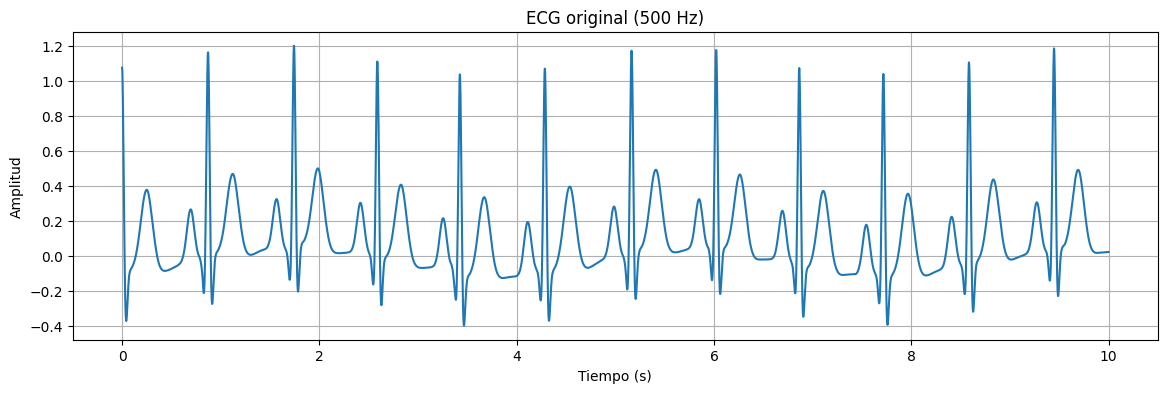

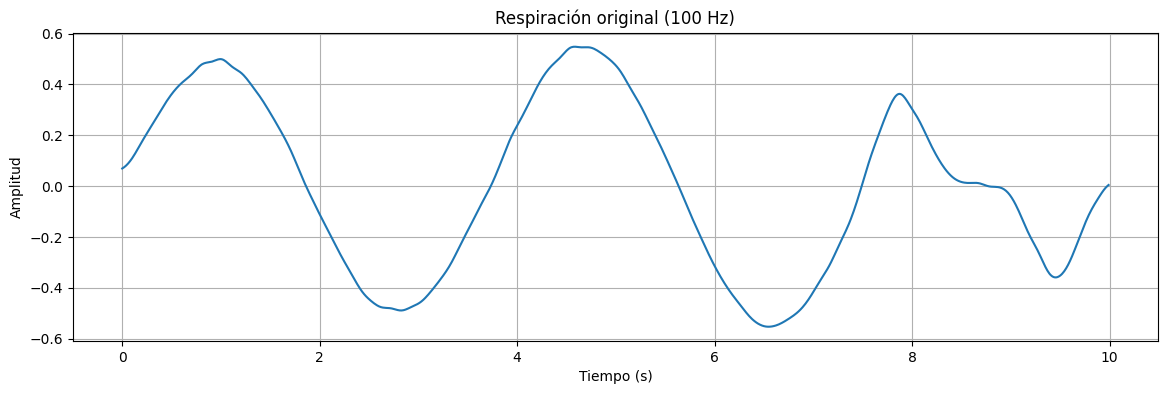

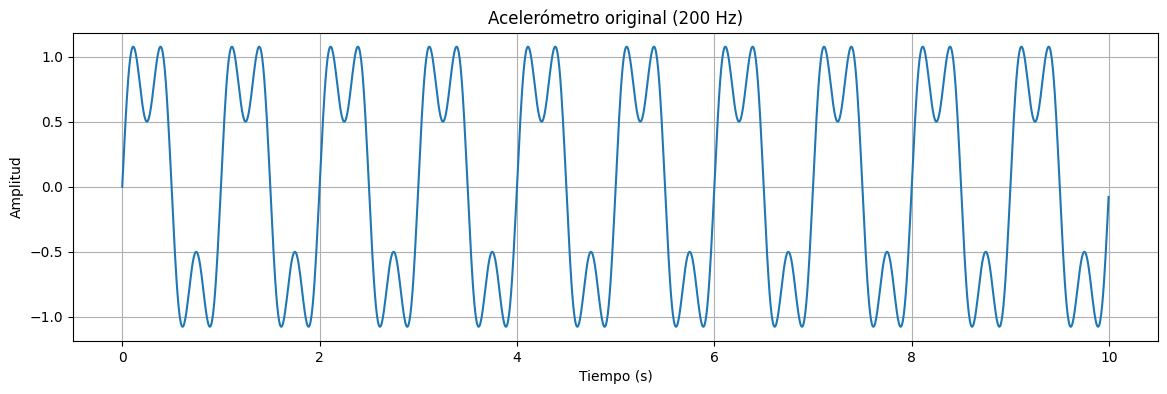

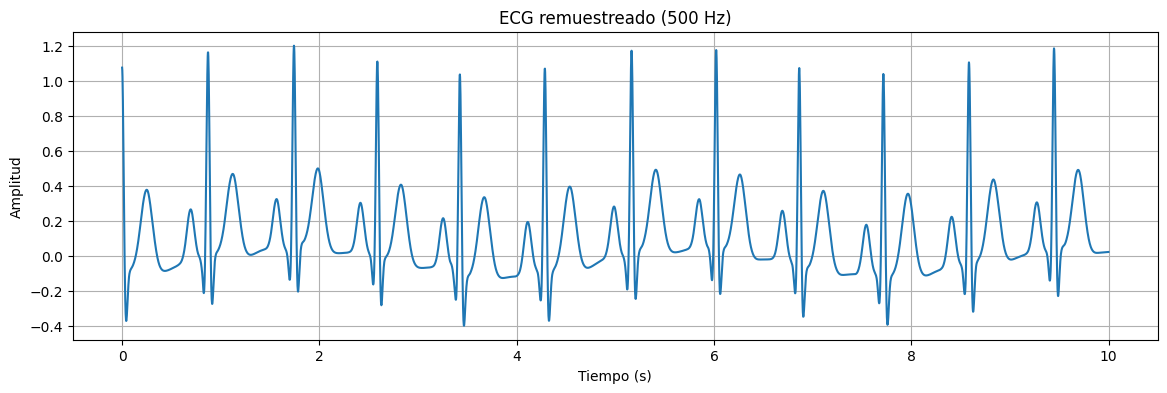

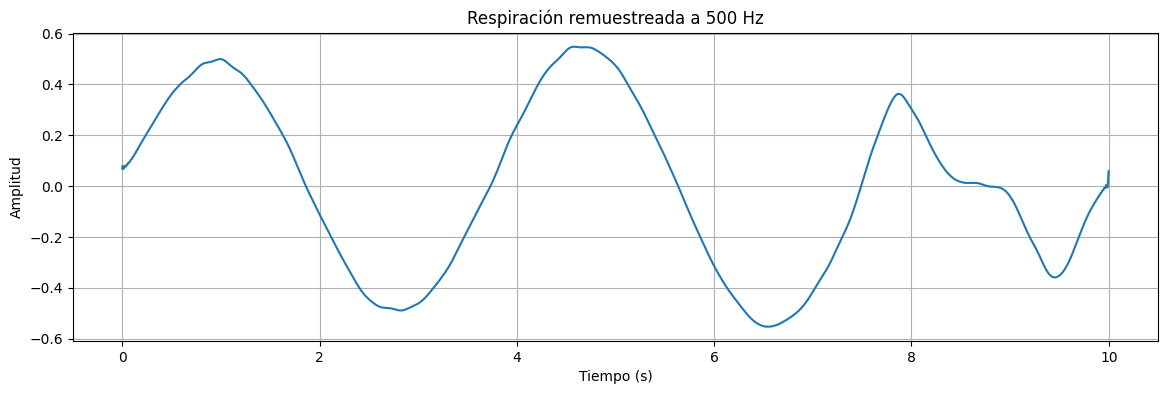

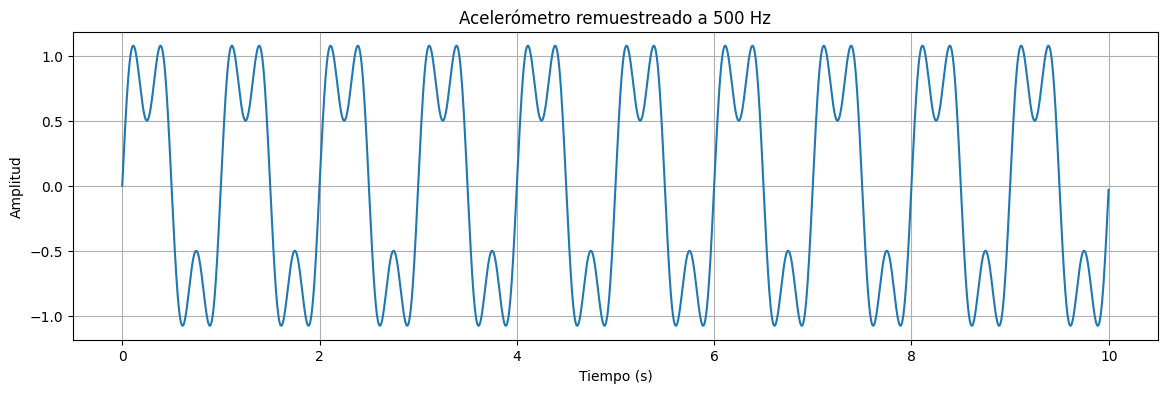

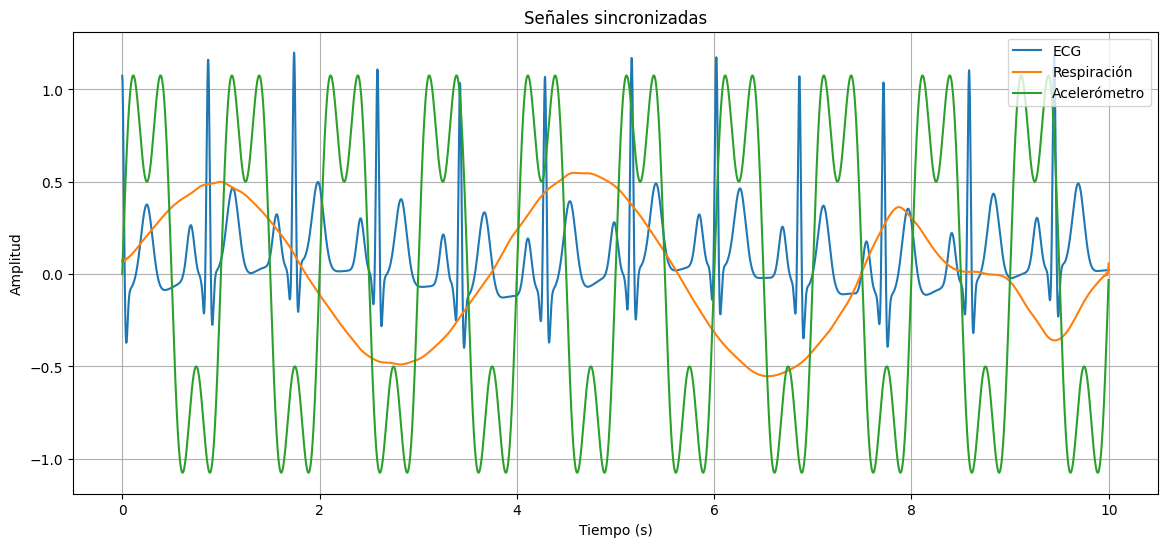

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, resample
import neurokit2 as nk

# Ejercicio 6

# Duración de la señal
duration = 10

# Frecuencias de muestreo
fs_ecg = 500
fs_rsp = 100
fs_acc = 200

# Frecuencia objetivo
fs_target = 500

# Señal de ECG a 500 Hz
t_ecg = np.linspace(0, duration, fs_ecg * duration, endpoint=False)

ecg = nk.ecg_simulate(duration=duration, sampling_rate=fs_ecg)

# Señal de respiración a 100 Hz
t_rsp = np.linspace(0, duration, fs_rsp * duration, endpoint=False)

rsp = nk.rsp_simulate(duration=duration, sampling_rate=fs_rsp, respiratory_rate=15)

# Señal del acelerómetro a 200 Hz
t_acc = np.linspace(0, duration, fs_acc * duration, endpoint=False)

acc = (
    1.0 * np.sin(2*np.pi*1*t_acc)
    +
    0.5 * np.sin(2*np.pi*3*t_acc)
)

# Remuestreo de las señales a 500 Hz
target_samples = fs_target * duration

# ECG ya está a 500 Hz
ecg_resampled = ecg

# Respiración 100 -> 500 Hz
rsp_resampled = resample(rsp, target_samples)

# Acelerómetro 200 -> 500 Hz
acc_resampled = resample(acc, target_samples)

# Tiempo remuestreado
t = np.linspace(0, duration, target_samples, endpoint=False)

# Plots de las señales originales

plt.figure(figsize=(14,4))
plt.plot(t_ecg, ecg)
plt.title("ECG original (500 Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


plt.figure(figsize=(14,4))
plt.plot(t_rsp, rsp)
plt.title("Respiración original (100 Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


plt.figure(figsize=(14,4))
plt.plot(t_acc, acc)
plt.title("Acelerómetro original (200 Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# Plots de las señales remuestreadas

plt.figure(figsize=(14,4))
plt.plot(t, ecg_resampled, label='ECG')
plt.title("ECG remuestreado (500 Hz)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


plt.figure(figsize=(14,4))
plt.plot(t, rsp_resampled, label='Respiración')
plt.title("Respiración remuestreada a 500 Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


plt.figure(figsize=(14,4))
plt.plot(t, acc_resampled, label='Acelerómetro')
plt.title("Acelerómetro remuestreado a 500 Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# Sincronización de las señales

plt.figure(figsize=(14,6))
plt.plot(t, ecg_resampled, label='ECG')
plt.plot(t, rsp_resampled, label='Respiración')
plt.plot(t, acc_resampled, label='Acelerómetro')
plt.title("Señales sincronizadas")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()
